# Import de Bibliotecas

In [ ]:
# Sessão 1: Importação de pacotes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import httpx 
import geopandas as gpd
import wget

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


# Exploração inicial dos países disponíveis

In [89]:
# Exploração inicial da API
url = "http://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.CD?format=json&per_page=50"
response = httpx.get(url, follow_redirects=True)

print("Status da resposta:", response.status_code)

# Converter para JSON
data = response.json()
df_preview = pd.DataFrame(data[1])

# Mostrar colunas disponíveis
print("\nColunas disponíveis no DataFrame:")
print(df_preview.columns.tolist())


Status da resposta: 200

Colunas disponíveis no DataFrame:
['indicator', 'country', 'countryiso3code', 'date', 'value', 'unit', 'obs_status', 'decimal']


In [90]:
# Mostrar primeiras linhas
print("\nPreview das primeiras linhas:")
display(df_preview.head(10))


Preview das primeiras linhas:


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,1.358694e+12,,,0
1,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,1.252564e+12,,,0
2,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1.179122e+12,,,0
3,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1.226461e+12,,,0
4,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1.113060e+12,,,0
5,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,9.385461e+11,,,0
6,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2019,1.019354e+12,,,0
7,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2018,1.021972e+12,,,0
8,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2017,9.792406e+11,,,0
9,"{'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (curren...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2016,8.326614e+11,,,0


In [91]:
# Mostrar tipos de dados
print("\nTipos de dados por coluna:")
print(df_preview.dtypes)


Tipos de dados por coluna:
indicator           object
country             object
countryiso3code        str
date                   str
value              float64
unit                   str
obs_status             str
decimal              int64
dtype: object


In [92]:

# Mostrar estatísticas básicas da coluna 'value'
print("\nEstatísticas básicas da coluna 'value':")
print(df_preview["value"].describe())


Estatísticas básicas da coluna 'value':
count    5.000000e+01
mean     5.277527e+11
std      3.886019e+11
min      9.600658e+10
25%      2.106804e+11
50%      2.819807e+11
75%      9.313859e+11
max      1.358694e+12
Name: value, dtype: float64


In [93]:
# Sessão 3: Listagem de países disponíveis
url_countries = "http://api.worldbank.org/v2/country?format=json&per_page=400"
response_countries = httpx.get(url_countries, follow_redirects=True)
data_countries = response_countries.json()

df_countries = pd.DataFrame(data_countries[1])

# Transformar colunas que são dicionários em strings legíveis
df_countries["region"] = df_countries["region"].apply(lambda x: x.get("value") if isinstance(x, dict) else x)
df_countries["incomeLevel"] = df_countries["incomeLevel"].apply(lambda x: x.get("value") if isinstance(x, dict) else x)

# Selecionar colunas principais e remover duplicados
df_countries_clean = df_countries[["id", "name", "region", "incomeLevel"]].drop_duplicates()

print("Total de países disponíveis:", df_countries_clean.shape[0])
display(df_countries_clean.head(20))


Total de países disponíveis: 295


,id,name,region,incomeLevel
0,ABW,Aruba,Latin America & Caribbean,High income
1,AFE,Africa Eastern and Southern,Aggregates,Aggregates
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,AFR,Africa,Aggregates,Aggregates
4,AFW,Africa Western and Central,Aggregates,Aggregates
5,AGO,Angola,Sub-Saharan Africa,Lower middle income
6,ALB,Albania,Europe & Central Asia,Upper middle income
7,AND,Andorra,Europe & Central Asia,High income
8,ARB,Arab World,Aggregates,Aggregates
9,ARE,United Arab Emirates,"Middle East, North Africa, Afghanistan & Pakistan",High income


# Filtando Paises da America Latina

In [94]:
# Sessão 4: Filtragem dos países da América Latina
latin_df = df_countries_clean[df_countries_clean["region"].str.contains("Latin America", na=False)]

print("Total de países latino-americanos:", latin_df.shape[0])
display(latin_df)


Total de países latino-americanos: 42


,id,name,region,incomeLevel
0,ABW,Aruba,Latin America & Caribbean,High income
10,ARG,Argentina,Latin America & Caribbean,Upper middle income
13,ATG,Antigua and Barbuda,Latin America & Caribbean,High income
27,BHS,"Bahamas, The",Latin America & Caribbean,High income
31,BLZ,Belize,Latin America & Caribbean,Upper middle income
34,BOL,Bolivia,Latin America & Caribbean,Lower middle income
35,BRA,Brazil,Latin America & Caribbean,Upper middle income
36,BRB,Barbados,Latin America & Caribbean,High income
49,CHL,Chile,Latin America & Caribbean,High income
57,COL,Colombia,Latin America & Caribbean,Upper middle income


In [95]:
# Sessão 5: Extração dos códigos ISO
latin_codes = latin_df["id"].drop_duplicates().tolist()

print("Códigos ISO dos países latino-americanos:")
print(latin_codes)


Códigos ISO dos países latino-americanos:
['ABW', 'ARG', 'ATG', 'BHS', 'BLZ', 'BOL', 'BRA', 'BRB', 'CHL', 'COL', 'CRI', 'CUB', 'CUW', 'CYM', 'DMA', 'DOM', 'ECU', 'GRD', 'GTM', 'GUY', 'HND', 'HTI', 'JAM', 'KNA', 'LCA', 'MAF', 'MEX', 'NIC', 'PAN', 'PER', 'PRI', 'PRY', 'SLV', 'SUR', 'SXM', 'TCA', 'TTO', 'URY', 'VCT', 'VEN', 'VGB', 'VIR']


In [98]:
# Sessão 6: Coleta de múltiplos indicadores
indicators = {
    "GDP": "NY.GDP.MKTP.CD",
    "Population": "SP.POP.TOTL",
    "GNI_per_capita": "NY.GNP.PCAP.CD",
    "Life_expectancy": "SP.DYN.LE00.IN",
    "School_enrollment_secondary": "SE.SEC.ENRR"
}

def get_multi_indicator(country_list, indicators_dict):
    frames = []
    for name, code in indicators_dict.items():
        for country in country_list:
            url = f"http://api.worldbank.org/v2/country/{country}/indicator/{code}?format=json&per_page=2000"
            response = httpx.get(url, follow_redirects=True)
            data = response.json()
            df = pd.DataFrame(data[1])
            df["country"] = country
            df = df[["country","date","value"]].dropna()
            df["date"] = df["date"].astype(int)
            df["value"] = pd.to_numeric(df["value"], errors="coerce")
            df.rename(columns={"value":name}, inplace=True)
            frames.append(df)
    return pd.concat(frames)

df_all = get_multi_indicator(latin_codes, indicators)

print("Preview dos dados coletados:")
display(df_all.head(20))


Preview dos dados coletados:


,country,date,GDP,Population,GNI_per_capita,Life_expectancy,School_enrollment_secondary
1,ABW,2024,4.167588e+09,NaN,NaN,NaN,NaN
2,ABW,2023,3.746573e+09,NaN,NaN,NaN,NaN
3,ABW,2022,3.326671e+09,NaN,NaN,NaN,NaN
4,ABW,2021,2.889305e+09,NaN,NaN,NaN,NaN
5,ABW,2020,2.461056e+09,NaN,NaN,NaN,NaN
6,ABW,2019,3.347562e+09,NaN,NaN,NaN,NaN
7,ABW,2018,3.276188e+09,NaN,NaN,NaN,NaN
8,ABW,2017,3.092428e+09,NaN,NaN,NaN,NaN
9,ABW,2016,2.983637e+09,NaN,NaN,NaN,NaN
10,ABW,2015,2.962907e+09,NaN,NaN,NaN,NaN


In [97]:
# Pivotar para ter colunas por indicador
df_pivot = df_all.pivot_table(index=["country","date"], 
                              values=list(indicators.keys()), 
                              aggfunc="mean").reset_index()

print("Preview dos dados organizados:")
display(df_pivot.head(15))


Preview dos dados organizados:


,country,date,GDP,GNI_per_capita,Life_expectancy,Population,School_enrollment_secondary
0,ABW,1960,NaN,NaN,64.049,54922.0,NaN
1,ABW,1961,NaN,NaN,64.215,55578.0,NaN
2,ABW,1962,NaN,NaN,64.602,56320.0,NaN
3,ABW,1963,NaN,NaN,64.944,57002.0,NaN
4,ABW,1964,NaN,NaN,65.303,57619.0,NaN
5,ABW,1965,NaN,NaN,65.615,58190.0,NaN
6,ABW,1966,NaN,NaN,66.126,58694.0,NaN
7,ABW,1967,NaN,NaN,66.385,58990.0,NaN
8,ABW,1968,NaN,NaN,66.744,59069.0,NaN
9,ABW,1969,NaN,NaN,67.098,59052.0,NaN


In [99]:
# Criar dicionário de códigos ISO → nomes
country_map = dict(zip(df_countries_clean["id"], df_countries_clean["name"]))

# Adicionar coluna com nome completo
df_pivot["country_name"] = df_pivot["country"].map(country_map)

# Conferir
print("Preview com nomes completos:")
display(df_pivot[["country","country_name","date"]].head(10))


Preview com nomes completos:


,country,country_name,date
0,ABW,Aruba,1960
1,ABW,Aruba,1961
2,ABW,Aruba,1962
3,ABW,Aruba,1963
4,ABW,Aruba,1964
5,ABW,Aruba,1965
6,ABW,Aruba,1966
7,ABW,Aruba,1967
8,ABW,Aruba,1968
9,ABW,Aruba,1969


# Sessão de Gráficos

## Renda per capita
Top 10 países da América Latina por Renda per capita (2020)

---

## Expectativa de vida
Top 10 países da América Latina por Expectativa de Vida (2020)

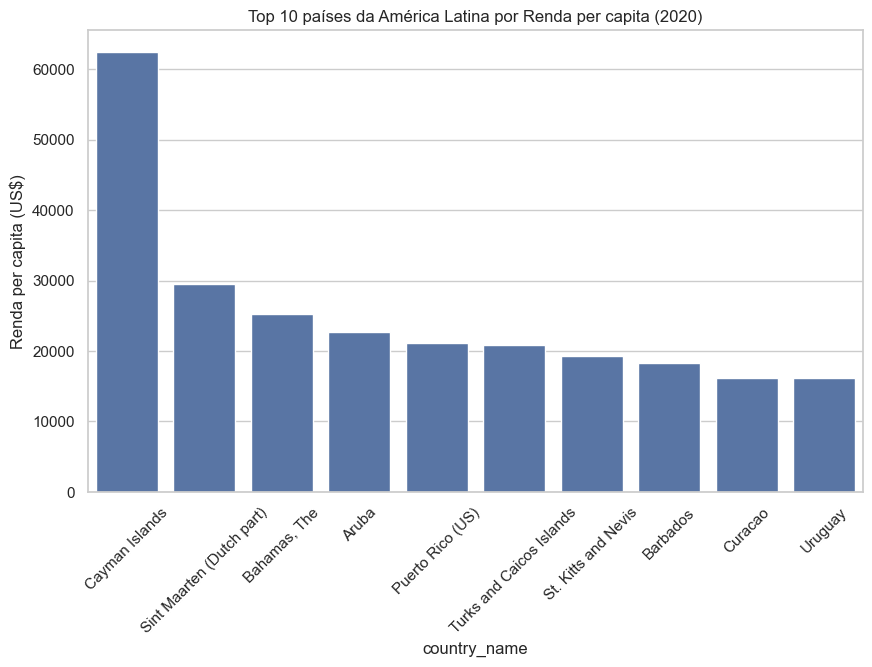

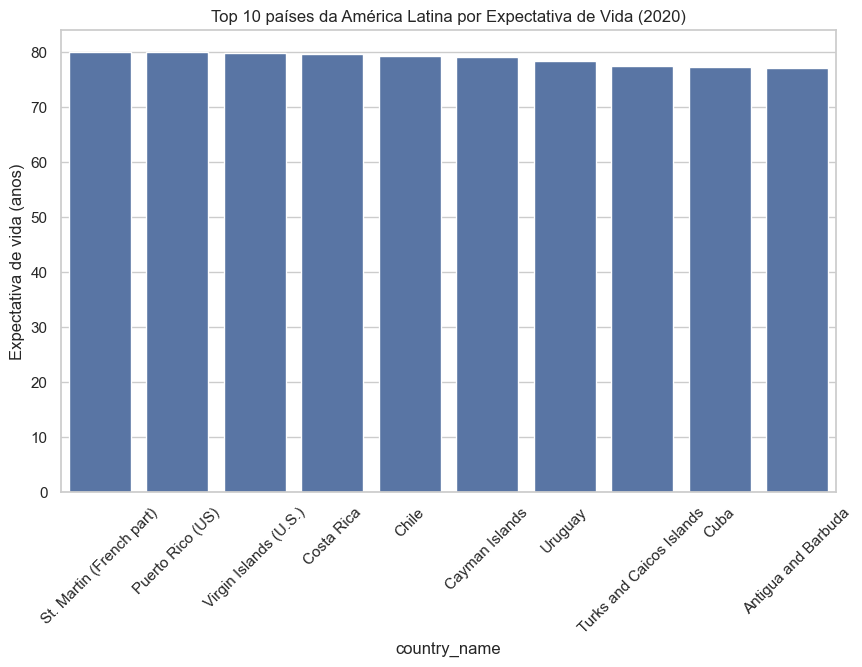

In [100]:
# Top países por GNI per capita em 2020 (com nomes)
top_gni = df_pivot[df_pivot["date"]==2020].sort_values("GNI_per_capita", ascending=False).head(10)
sns.barplot(data=top_gni, x="country_name", y="GNI_per_capita")
plt.title("Top 10 países da América Latina por Renda per capita (2020)")
plt.ylabel("Renda per capita (US$)")
plt.xticks(rotation=45)
plt.show()

# Expectativa de vida comparativa (com nomes)
top_life = df_pivot[df_pivot["date"]==2020].sort_values("Life_expectancy", ascending=False).head(10)
sns.barplot(data=top_life, x="country_name", y="Life_expectancy")
plt.title("Top 10 países da América Latina por Expectativa de Vida (2020)")
plt.ylabel("Expectativa de vida (anos)")
plt.xticks(rotation=45)
plt.show()


## Renda per capita (BRA X ARG)
Top 10 países da América Latina por Renda per capita (2020)

---

## Expectativa de vida (BRA X ARG)
Top 10 países da América Latina por Expectativa de Vida (2020)

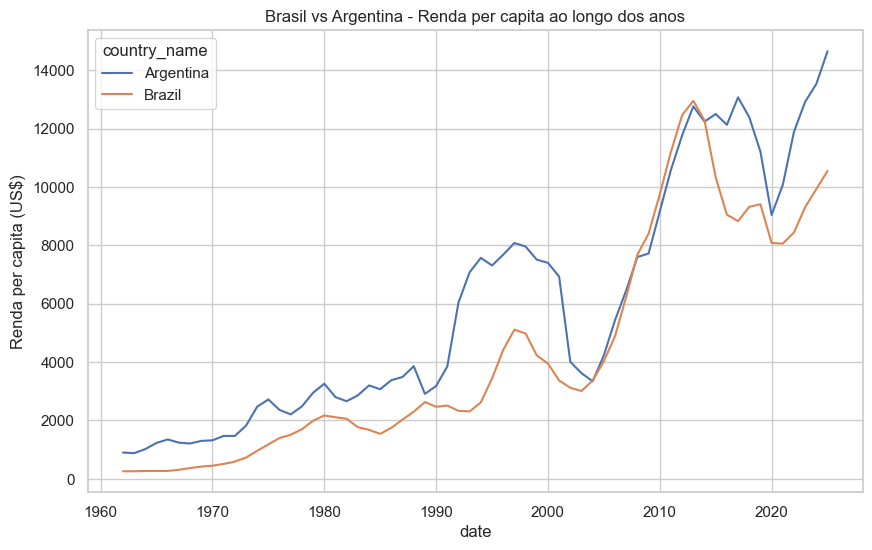

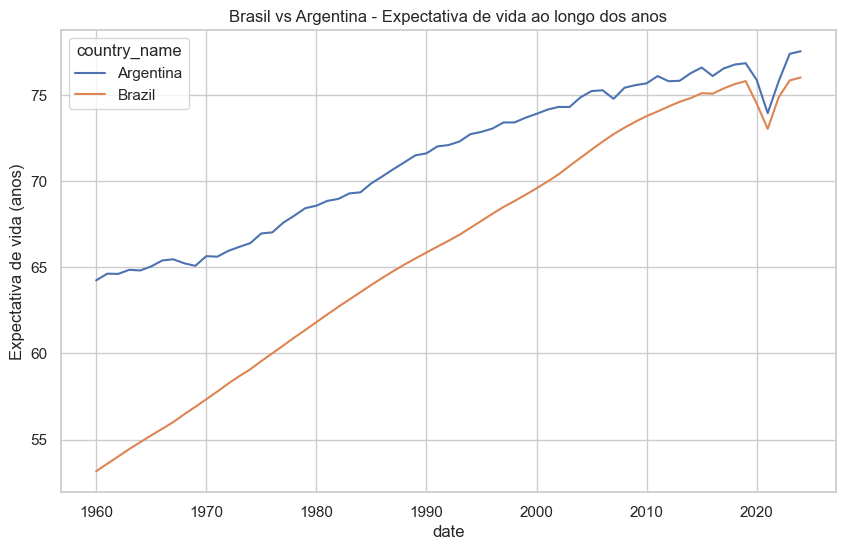

In [ ]:
df_compare = df_pivot[df_pivot["country"].isin(["BRA","ARG"])]

sns.lineplot(data=df_compare, x="date", y="GNI_per_capita", hue="country_name")
plt.title("Brasil vs Argentina - Renda per capita ao longo dos anos")
plt.ylabel("Renda per capita (US$)")
plt.show()

sns.lineplot(data=df_compare, x="date", y="Life_expectancy", hue="country_name")
plt.title("Brasil vs Argentina - Expectativa de vida ao longo dos anos")
plt.ylabel("Expectativa de vida (anos)")
plt.show()


## Top 10 rendas per captas da america latina

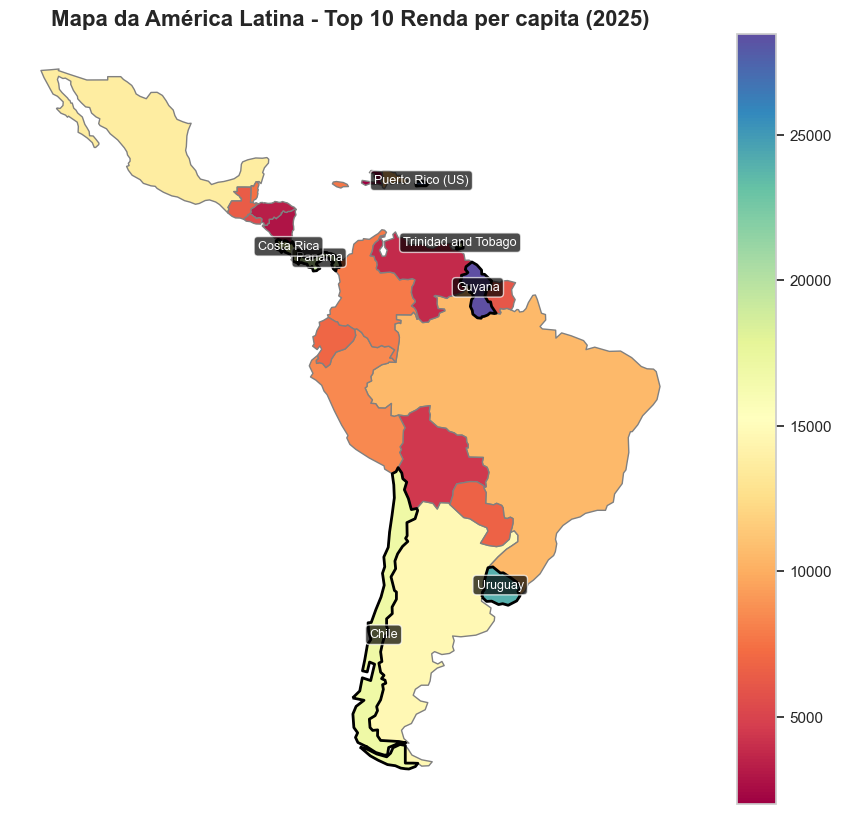

In [ ]:


# 🔹 Baixar shapefile de países (Natural Earth 110m)
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
wget.download(url, "countries.zip")

# Ler shapefile
world = gpd.read_file("zip://countries.zip")

# 🔹 Filtrar América Latina
latin = world[world["CONTINENT"].isin(["North America","South America"])]

# 🔹 Dados de 2025
df_2025 = df_pivot[df_pivot["date"]==2025].dropna(subset=["GNI_per_capita"])

# Top 10 países por renda per capita
top10 = df_2025.sort_values("GNI_per_capita", ascending=False).head(10)

# 🔹 Juntar shapefile com dados
latin = latin.merge(df_2025, left_on="ISO_A3", right_on="country", how="left")

# 🔹 Plotar mapa com paleta mais bonita
fig, ax = plt.subplots(1, 1, figsize=(12,10))
latin.plot(column="GNI_per_capita", cmap="Spectral", legend=True, ax=ax, edgecolor="gray")

# Destacar os Top 10 com borda preta grossa
latin[latin["country"].isin(top10["country"])].boundary.plot(ax=ax, color="black", linewidth=2)

# 🔹 Adicionar labels nos Top 10
for idx, row in latin[latin["country"].isin(top10["country"])].iterrows():
    plt.text(row.geometry.centroid.x, row.geometry.centroid.y,
             row["country_name"], fontsize=9, ha="center", color="white",
             bbox=dict(facecolor="black", alpha=0.7, boxstyle="round,pad=0.3"))

plt.title("Mapa da América Latina - Top 10 Renda per capita (2025)", fontsize=16, fontweight="bold")
plt.axis("off")
plt.show()


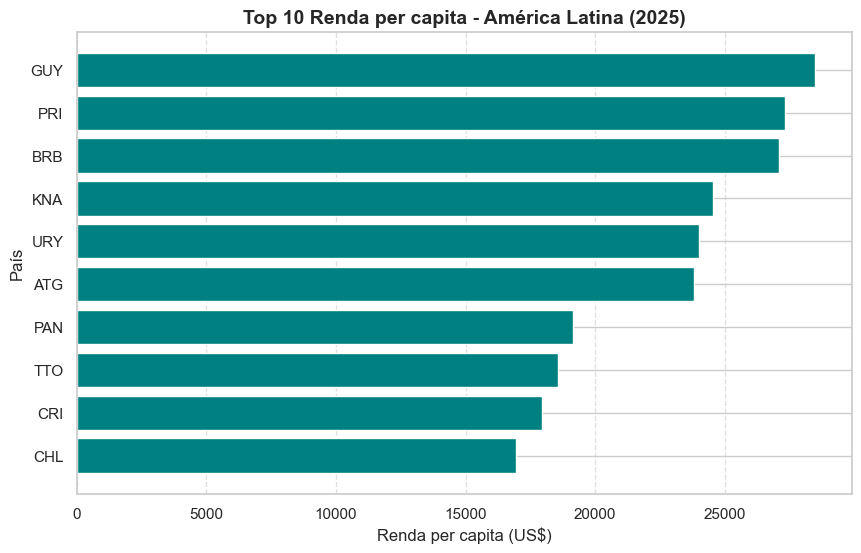

In [85]:
import matplotlib.pyplot as plt

# 🔹 Pegar último ano com dados válidos
latest_year = df_all.dropna(subset=["GNI_per_capita"])["date"].max()
df_latest = df_all[df_all["date"] == latest_year].dropna(subset=["GNI_per_capita"])

# 🔹 Ordenar países por renda per capita
df_rank = df_latest.sort_values("GNI_per_capita", ascending=False).head(10)

# 🔹 Plotar gráfico de barras
plt.figure(figsize=(10,6))
plt.barh(df_rank["country"], df_rank["GNI_per_capita"], color="teal")
plt.gca().invert_yaxis()  # maior no topo
plt.title(f"Top 10 Renda per capita - América Latina ({latest_year})", fontsize=14, fontweight="bold")
plt.xlabel("Renda per capita (US$)")
plt.ylabel("País")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.show()
